## A First Attempt at Dark Matter Abundance

In [ ]:
import numpy as np 
import pandas as pd 
import os 
from cytools import fetch_polytopes 

OUTPUT_CSV = "dark_matter_data_exact.csv" 

TAU_MAX = 75.0 # max divisor volume 
LOG_LAMBDA_MIN = -700.0 # fail-safe for low instanton scales 
Mpl = 1.0 
Omega_r = 9.2e-5                    # radiation density today 
Omega_DM = 0.12                     # observed DM abundance (Omega h^2) 
H0_eV = 1.44e-33                    # Hubble constant in eV 

avg_theta = np.sqrt(np.pi**2/3)     # avg misalignment angle
theta_i = 1                         # initial misalignment angle 


Mpl_GeV = 2.435e18 
GeV_to_eV = 1e9 

h11_dict = {
    h11: 1
    for h11 in range(1, 492)
}

def write_row(row: dict) -> None: 
    df = pd.DataFrame([row]) 
    write_header = not os.path.isfile(OUTPUT_CSV) or os.path.getsize(OUTPUT_CSV) == 0 
    df.to_csv(OUTPUT_CSV, mode="a", header=write_header, index=False) 
    
for h11, n_cy3 in h11_dict.items(): 
    print(f"\n=== h11 = {h11} ===") 
        
    try: 
        polys = fetch_polytopes(h11=h11, lattice="N", favorable=True, limit=n_cy3) 
    except Exception as e: 
        print(f" Failed to fetch polytopes for h11={h11}: {e}") 
        continue

    for cy_index, p in enumerate(polys):
        try:
            cy = p.triangulate(backend="topcom").get_cy()

            tip = cy.toric_kahler_cone().tip_of_stretched_cone(1)
            taus = cy.compute_divisor_volumes(tip, in_basis=True)
            K = cy.compute_kahler_metric(tip)
            vol = cy.compute_cy_volume(tip)

            if not np.all(np.isfinite(K)):
                print(f"  CY {cy_index}: non-finite Kähler metric, skipping")
                continue
            evals = np.linalg.eigvalsh(K)
            if np.any(evals <= 0):
                print(f"  CY {cy_index}: Kähler metric not positive definite, skipping")
                continue

            L_chol = np.linalg.cholesky(K)
            f = np.diag(L_chol) / (2.0 * np.pi)  

            log_Lambda4 = -2.0 * np.pi * taus
            active_mask = (taus <= TAU_MAX) & (log_Lambda4 > LOG_LAMBDA_MIN)
            Lambda4 = np.where(active_mask, np.exp(log_Lambda4), 0.0)

            active = int(np.count_nonzero(active_mask))
            print(f"  CY {cy_index}: active instantons = {active} / {len(taus)}")

            if active == 0:
                print(f"  CY {cy_index}: no contributing instantons, skipping")
                continue

            Lambda2 = np.sqrt(Lambda4)  

            for i in np.where(active_mask)[0]:
                m = Lambda2[i] / f[i]
                m_eV = m * Mpl_GeV * GeV_to_eV
                if m_eV <= H0_eV:
                    continue
                f_GeV = f[i] * Mpl_GeV

                Omega_a = ( (1/6) * (9.0 * Omega_r)**0.75 * np.sqrt(m_eV / H0_eV) * theta_i**2 * (f_GeV / Mpl_GeV)**2)

                fraction_DM = Omega_a / Omega_DM

                write_row({ 
                    "h11": h11, 
                    "cy_index": cy_index, 
                    "axion_index": int(i), 
                    "tau": float(taus[i]), 
                    "f_GeV": float(f[i]) * Mpl_GeV, 
                    "Lambda2_GeV": float(Lambda2[i]) * Mpl_GeV, 
                    "mass_eV": float(Lambda2[i] / f[i]) * Mpl_GeV * GeV_to_eV, 
                    "Omega_a": float(Omega_a), 
                    "fraction_DM": float(fraction_DM), 
                    "cy_volume": vol })

        except Exception as e:
            continue

## Effective Photon Coupling

In [ ]:
import numpy as np 
import pandas as pd 
import os 
from cytools import fetch_polytopes 

OUTPUT_CSV = "dark_matter_photon_stuff.csv" 

TAU_MAX = 75.0
LOG_LAMBDA_MIN = -700.0
Mpl = 1.0 
Omega_r = 9.2e-5
Omega_DM = 0.12
H0_eV = 1.44e-33

avg_theta = np.sqrt(np.pi**2/3)
theta_i = 1

Mpl_GeV = 2.435e18 
GeV_to_eV = 1e9

alpha_em = 1 / 137.0

h11_dict = {
    h11: 10
    for h11 in range(1, 492)
}

def g_eff_axion_photon(f_vals):
    return (alpha_em / (2 * np.pi)) * np.sqrt(np.sum(1.0 / f_vals**2))

def write_row(row: dict) -> None: 
    df = pd.DataFrame([row]) 
    write_header = not os.path.isfile(OUTPUT_CSV) or os.path.getsize(OUTPUT_CSV) == 0 
    df.to_csv(OUTPUT_CSV, mode="a", header=write_header, index=False) 
    
for h11, n_cy3 in h11_dict.items(): 
    print(f"\n=== h11 = {h11} ===") 
        
    try: 
        polys = fetch_polytopes(h11=h11, lattice="N", favorable=True, limit=n_cy3) 
    except Exception as e: 
        print(f" Failed to fetch polytopes for h11={h11}: {e}") 
        continue

    for cy_index, p in enumerate(polys):
        try:
            cy = p.triangulate(backend="cgal").get_cy()

            tip = cy.toric_kahler_cone().tip_of_stretched_cone(1)
            taus = cy.compute_divisor_volumes(tip, in_basis=True)
            K = cy.compute_kahler_metric(tip)
            vol = cy.compute_cy_volume(tip)

            if not np.all(np.isfinite(K)):
                print(f"  CY {cy_index}: non-finite Kähler metric, skipping")
                continue
            evals = np.linalg.eigvalsh(K)
            if np.any(evals <= 0):
                print(f"  CY {cy_index}: Kähler metric not positive definite, skipping")
                continue

            L_chol = np.linalg.cholesky(K)
            f = np.diag(L_chol) / (2.0 * np.pi)

            log_Lambda4 = -2.0 * np.pi * taus
            active_mask = (taus <= TAU_MAX) & (log_Lambda4 > LOG_LAMBDA_MIN)
            Lambda4 = np.where(active_mask, np.exp(log_Lambda4), 0.0)

            active = int(np.count_nonzero(active_mask))
            print(f"  CY {cy_index}: active instantons = {active} / {len(taus)}")

            if active == 0:
                print(f"  CY {cy_index}: no contributing instantons, skipping")
                continue

            # compute g_eff over all active axions in this compactification
            f_active_GeV = f[active_mask] * Mpl_GeV
            g_eff = g_eff_axion_photon(f_active_GeV)

            for i in np.where(active_mask)[0]:
                write_row({ 
                    "h11": h11, 
                    "cy_index": cy_index, 
                    "axion_index": int(i), 
                    "tau": float(taus[i]), 
                    "f_GeV": float(f[i]) * Mpl_GeV,
                    "g_eff_GeV_inv": float(g_eff),
                    "cy_volume": vol,
                })

        except Exception as e:
            continue

## Testing out GNN Triangulations

In [ ]:
import numpy as np 
import pandas as pd 
import os 
from cytools import fetch_polytopes 

OUTPUT_CSV = "gnn_triangulations_test2.csv" 

TAU_MAX = 75.0
LOG_LAMBDA_MIN = -700.0
Mpl = 1.0 
Omega_r = 9.2e-5
Omega_DM = 0.12
H0_eV = 1.44e-33

avg_theta = np.sqrt(np.pi**2/3)
theta_i = 1

Mpl_GeV = 2.435e18 
GeV_to_eV = 1e9

alpha_em = 1 / 137.0

h11_dict = {
    h11: {"n_poly": 5, "n_triag": 10}
    for h11 in range(1, 492)
}

def write_row(row: dict) -> None: 
    df = pd.DataFrame([row]) 
    write_header = not os.path.isfile(OUTPUT_CSV) or os.path.getsize(OUTPUT_CSV) == 0 
    df.to_csv(OUTPUT_CSV, mode="a", header=write_header, index=False) 

def g_eff_axion_photon(f_GeV):
    return (alpha_em / (2 * np.pi)) / f_GeV
    
for h11, cfg in h11_dict.items():
    print(f"\n=== h11 = {h11} ===") 
    n_poly  = cfg["n_poly"]
    n_triag = cfg["n_triag"]
    
    try:
        polys = fetch_polytopes(h11=h11, lattice="N", favorable=True, limit=n_poly)
    except Exception as e:
        print(f"  Failed to fetch polytopes: {e}")
        continue

    for cy_index, p in enumerate(polys):
        print(f"\n  Polytope {cy_index}")
        try:
            triag_gen = p.random_triangulations_gnn(N=n_triag)
            
            for triag_index, triag in enumerate(triag_gen):
                if triag_index >= n_triag:
                    break
                try:
                    cy = triag.get_cy()
                    tip = cy.toric_kahler_cone().tip_of_stretched_cone(1)
                    vol = cy.compute_cy_volume(tip)
                    taus = cy.compute_divisor_volumes(tip, in_basis=True)
                    K = cy.compute_kahler_metric(tip)

                    if not np.all(np.isfinite(K)):
                        print(f"  CY {cy_index}: non-finite Kähler metric, skipping")
                        continue
                    evals = np.linalg.eigvalsh(K)
                    if np.any(evals <= 0):
                        print(f"  CY {cy_index}: Kähler metric not positive definite, skipping")
                        continue

                    L_chol = np.linalg.cholesky(K)
                    f = np.diag(L_chol) / (2.0 * np.pi)

                    log_Lambda4 = -2.0 * np.pi * taus
                    active_mask = (taus <= TAU_MAX) & (log_Lambda4 > LOG_LAMBDA_MIN)
                    Lambda4 = np.where(active_mask, np.exp(log_Lambda4), 0.0)

                    active = int(np.count_nonzero(active_mask))
                    print(f"  CY {cy_index}: active instantons = {active} / {len(taus)}")

                    if active == 0:
                        print(f"  CY {cy_index}: no contributing instantons, skipping")
                        continue

                    f_active_GeV = f[active_mask] * Mpl_GeV
                    g_eff = g_eff_axion_photon(f_active_GeV)

                    for i, axion_idx in enumerate(np.where(active_mask)[0]):
                        Lambda4_GeV4 = np.exp(-2 * np.pi * taus[axion_idx]) * Mpl_GeV**4
                        m_eV = np.sqrt(Lambda4_GeV4) / f_active_GeV[i] * GeV_to_eV

                        write_row({
                            "h11":          h11,
                            "cy_index":     cy_index,
                            "triag_index":  triag_index,
                            "tau":          taus[axion_idx],
                            "cy_volume":    vol,
                            "f_GeV":        f_active_GeV[i],
                            "g_eff_GeV_inv": g_eff[i],
                            "mass": m_eV
                        })
                    
                except Exception as e:
                    print(f"    triag {triag_index} failed: {e}")
                    continue

        except Exception as e:
            print(f"  Polytope {cy_index} failed: {e}")
            continue

## Polytope vs Triangulation Diversity

In [ ]:
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt

POLY_CSV  = "polytope_diversity.csv"
TRIAG_CSV = "triangulation_diversity.csv"

def geometry_statistics(csv_file):
    df = pd.read_csv(csv_file)

    df = df[
        (df["f_GeV"] > 0)
        & (df["mass"] > 0)
        & (df["g_eff_GeV_inv"] > 0)
    ].copy()

    df["logf"] = np.log10(df["f_GeV"])
    df["logm"] = np.log10(df["mass"])
    df["logg"] = np.log10(df["g_eff_GeV_inv"])

    geom = (
        df.groupby(["cy_index", "triag_index"])
        .agg(
            median_logf=("logf", "median"),
            median_logm=("logm", "median"),
            median_logg=("logg", "median"),
            n_axions=("logf", "size")
        )
        .reset_index()
    )

    stats = {
        "n_geometries": len(geom),

        "sigma_logf":
            geom["median_logf"].std(ddof=1),

        "sigma_logm":
            geom["median_logm"].std(ddof=1),

        "sigma_logg":
            geom["median_logg"].std(ddof=1),

        "median_logf":
            geom["median_logf"].median(),

        "median_logm":
            geom["median_logm"].median(),

        "median_logg":
            geom["median_logg"].median(),
    }

    return geom, stats


poly_geom, poly_stats = geometry_statistics(POLY_CSV)
triag_geom, triag_stats = geometry_statistics(TRIAG_CSV)

print("\n=== POLYTOPE VARIATION RUN ===")
for k, v in poly_stats.items():
    print(f"{k:20s}: {v}")

print("\n=== TRIANGULATION VARIATION RUN ===")
for k, v in triag_stats.items():
    print(f"{k:20s}: {v}")

print("\n=== RATIO (polytope / triangulation) ===")
print(f"sigma_logf ratio = {poly_stats['sigma_logf']/triag_stats['sigma_logf']:.3f}")
print(f"sigma_logm ratio = {poly_stats['sigma_logm']/triag_stats['sigma_logm']:.3f}")
print(f"sigma_logg ratio = {poly_stats['sigma_logg']/triag_stats['sigma_logg']:.3f}")

plt.hist(poly_geom["median_logm"],
         bins=30,
         alpha=0.5,
         label="100 polytopes")

plt.hist(triag_geom["median_logm"],
         bins=30,
         alpha=0.5,
         label="100 triangulations")

plt.legend()
plt.xlabel(r"median $\log_{10}(m/{\rm eV})$")

## A Functional Pipeline with Randmom Polytope Sampling

In [108]:
import numpy as np 
import pandas as pd 
import os 
from cytools import fetch_polytopes 

OUTPUT_CSV = "mock_fuzzy.csv" 

TAU_MAX = 75.0
LOG_LAMBDA_MIN = -700.0
Mpl = 1.0 
Omega_r = 9.2e-5
Omega_DM = 0.12
H0_eV = 1.44e-33

avg_theta = np.sqrt(np.pi**2/3)
theta_i = 1

Mpl_GeV = 2.435e18 
GeV_to_eV = 1e9

alpha_em = 1 / 137.0

h11_dict = {
    h11: {"n_poly": 100, "n_triag": 100}
    for h11 in range(2, 8)
}

def write_row(row: dict) -> None: 
    df = pd.DataFrame([row]) 
    write_header = not os.path.isfile(OUTPUT_CSV) or os.path.getsize(OUTPUT_CSV) == 0 
    df.to_csv(OUTPUT_CSV, mode="a", header=write_header, index=False) 

def g_eff_axion_photon(f_GeV):
    return (alpha_em / (2 * np.pi)) / f_GeV
    
for h11, cfg in h11_dict.items():
    print(f"\n=== h11 = {h11} ===") 
    n_poly  = cfg["n_poly"]
    n_triag = cfg["n_triag"]
    
    try:
        polys = fetch_polytopes(h11=h11, lattice="N", favorable=True, limit=n_poly)
    except Exception as e:
        print(f"  Failed to fetch polytopes: {e}")
        continue

    for cy_index, p in enumerate(polys):
        print(f"\n  Polytope {cy_index}")
        try:
            triag_gen = p.random_triangulations_fast(N=n_triag)
            print("Fetching a polytope...")
            
            for triag_index, triag in enumerate(triag_gen):
                if triag_index >= n_triag:
                    break
                try:
                    print("Found a polytope!")
                    cy = triag.get_cy()
                    print(f'Found a threefold: {cy}!')
                    tip = cy.toric_kahler_cone().tip_of_stretched_cone(1)
                    vol = cy.compute_cy_volume(tip)
                    taus = cy.compute_divisor_volumes(tip, in_basis=True)
                    K = cy.compute_kahler_metric(tip)

                    if not np.all(np.isfinite(K)):
                        print(f"  CY {cy_index}: non-finite Kähler metric, skipping")
                        continue
                    evals = np.linalg.eigvalsh(K)
                    if np.any(evals <= 0):
                        print(f"  CY {cy_index}: Kähler metric not positive definite, skipping")
                        continue

                    L_chol = np.linalg.cholesky(K)
                    f = np.diag(L_chol) / (2.0 * np.pi)

                    log_Lambda4 = -2.0 * np.pi * taus
                    active_mask = (taus <= TAU_MAX) & (log_Lambda4 > LOG_LAMBDA_MIN)
                    Lambda4 = np.where(active_mask, np.exp(log_Lambda4), 0.0)

                    active = int(np.count_nonzero(active_mask))
                    print(f"  CY {cy_index}: active instantons = {active} / {len(taus)}")

                    if active == 0:
                        print(f"  CY {cy_index}: no contributing instantons, skipping")
                        continue

                    f_active_GeV = f[active_mask] * Mpl_GeV
                    g_eff = g_eff_axion_photon(f_active_GeV)

                    for i, axion_idx in enumerate(np.where(active_mask)[0]):
                        Lambda4_GeV4 = np.exp(-2 * np.pi * taus[axion_idx]) * Mpl_GeV**4
                        m_eV = np.sqrt(Lambda4_GeV4) / f_active_GeV[i] * GeV_to_eV

                        write_row({
                            "h11":          h11,
                            "cy_index":     cy_index,
                            "triag_index":  triag_index,
                            "tau":          taus[axion_idx],
                            "cy_volume":    vol,
                            "f_GeV":        f_active_GeV[i],
                            "g_eff_GeV_inv": g_eff[i],
                            "mass": m_eV
                        })
                    
                except Exception as e:
                    print(f"    triag {triag_index} failed: {e}")
                    continue

        except Exception as e:
            print(f"  Polytope {cy_index} failed: {e}")
            continue


=== h11 = 2 ===
  Failed to fetch polytopes: ('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer'))

=== h11 = 3 ===
  Failed to fetch polytopes: ('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer'))

=== h11 = 4 ===


KeyboardInterrupt: 

## $f$ and $g_{a\gamma\gamma}$ vs $h^{1,1}$ plots

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.style.use("seaborn-v0_8-white")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "axes.linewidth": 1.5,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in"
})


df1 = pd.read_csv("/Users/Djslime07/Documents/GitHub/Dark-Matter-Abundance-Project/fast_h11_data/h11_1_176_fast.csv")
df2 = pd.read_csv("/Users/Djslime07/Documents/GitHub/Dark-Matter-Abundance-Project/fast_h11_data/h11_177_235_fast.csv")
df3 = pd.read_csv("/Users/Djslime07/Documents/GitHub/Dark-Matter-Abundance-Project/fast_h11_data/h11_236_291_fast.csv")
df4 = pd.read_csv("/Users/Djslime07/Documents/GitHub/Dark-Matter-Abundance-Project/fast_h11_data/h11_292_491_fast.csv")

df = pd.concat([df1, df2, df3, df4], ignore_index=True)
h11 = df['h11'].values
V = df['cy_volume'].values
f = df['f_GeV'].values
g_eff = df['g_eff_GeV_inv']
m = df['mass']

plt.figure(figsize=(10,6))
logh11 = np.log10(h11)
logf = np.log10(f)
plt.xlabel(r"$\log_{10}(h^{1,1})$")
plt.ylabel(r"$\log_{10}(f)$")
plt.scatter(logh11, logf)

plt.figure(figsize=(10,6))
logg_eff = np.log10(g_eff)
plt.xlabel(r"$\log_{10}(h^{1,1})$")
plt.ylabel(r"$\log_{10}(g_{a\gamma\gamma})$")
plt.scatter(logh11, logg_eff)

## Computing Dark Matter Abundance

In [104]:
import numpy as np
import pandas as pd

base = "/Users/Djslime07/Documents/GitHub/Dark-Matter-Abundance-Project/fast_h11_data/"

df1 = pd.read_csv(base + "h11_1_176_fast.csv")
df2 = pd.read_csv(base + "h11_177_235_fast.csv")
df3 = pd.read_csv(base + "h11_236_291_fast.csv")
df4 = pd.read_csv(base + "h11_292_491_fast.csv")

# Constants
Omega_r  = 9.2e-5
Omega_DM = 0.12
H0_eV    = 1.44e-33
Mpl_GeV  = 2.435e18
theta_i  = 0.1

def add_columns(df):
    df = df.copy()
    f_GeV = df['f_GeV'].values
    m_eV  = df['mass'].values
    df['Omega_a'] = (
        (1/6)
        * (9.0 * Omega_r)**0.75
        * np.sqrt(m_eV / H0_eV)
        * theta_i**2
        * (f_GeV / Mpl_GeV)**2
    )
    df['frac_DM'] = df['Omega_a'] / Omega_DM
    return df

df1 = add_columns(df1)
df2 = add_columns(df2)
df3 = add_columns(df3)
df4 = add_columns(df4)

df1.to_csv(base + "h11_1_176_fast_DM.csv",   index=False)
df2.to_csv(base + "h11_177_235_fast_DM.csv",  index=False)
df3.to_csv(base + "h11_236_291_fast_DM.csv",  index=False)
df4.to_csv(base + "h11_292_491_fast_DM.csv",  index=False)


## Dark Matter Abundance Plots

(-40.0, 10.0)

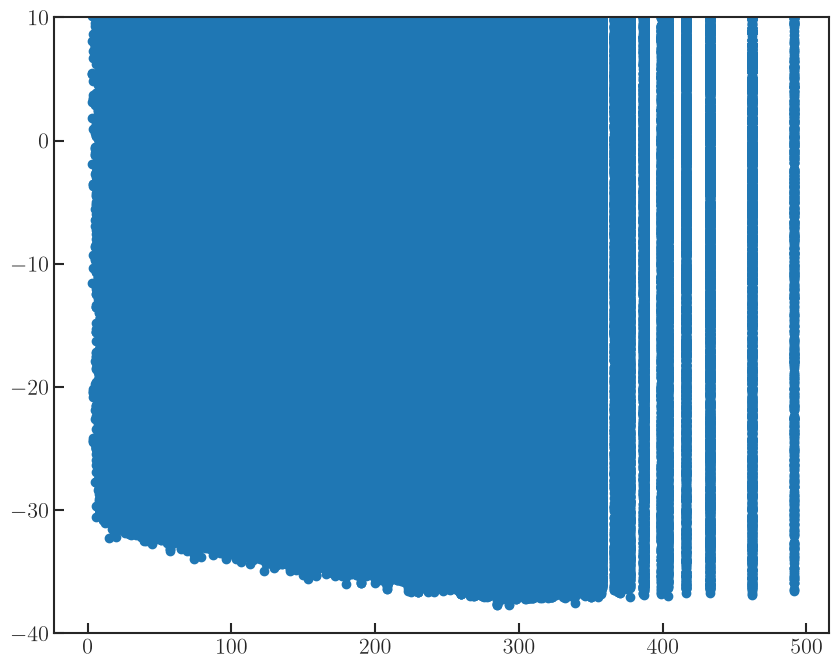

In [106]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.style.use("seaborn-v0_8-white")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "axes.linewidth": 1.5,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in"
})


df1 = pd.read_csv("/Users/Djslime07/Documents/GitHub/Dark-Matter-Abundance-Project/fast_h11_data/h11_1_176_fast_DM.csv")
df2 = pd.read_csv("/Users/Djslime07/Documents/GitHub/Dark-Matter-Abundance-Project/fast_h11_data/h11_177_235_fast_DM.csv")
df3 = pd.read_csv("/Users/Djslime07/Documents/GitHub/Dark-Matter-Abundance-Project/fast_h11_data/h11_236_291_fast_DM.csv")
df4 = pd.read_csv("/Users/Djslime07/Documents/GitHub/Dark-Matter-Abundance-Project/fast_h11_data/h11_292_491_fast_DM.csv")

df = pd.concat([df1, df2, df3, df4], ignore_index=True)
h11 = df['h11'].values
DM_frac = df['frac_DM'].values
logh11 = np.log10(h11)
logdm = np.log10(DM_frac)
plt.figure(figsize=(10,8))
plt.scatter(h11, logdm)
plt.ylim(-40, 10)